In [1]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
import numpy as np
from sklearn.model_selection import cross_validate, KFold

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from utils import eval, visual, save, save_model
from model import Model
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

# 1.Grain_1

In [3]:
data = pd.read_csv('data/compound_5_Structural_Grain1.csv').drop(columns=['compound'])
target_col = 'Grain_1'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(10)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 10
features: ['feat_16', 'feat_25', 'feat_9', 'feat_14', 'feat_8', 'feat_1', 'feat_5', 'feat_6', 'feat_3', 'feat_12']


5CV:
MSE: 119.2378 ± 54.0755
RMSE: 10.6430 ± 2.4420
MAE: 7.3535 ± 1.4428
R2: 0.6579 ± 0.1118


【train】:  MSE: 3.9038  RMSE: 1.9758  MAE: 1.0957, R2: 0.9889
【test】:  MSE: 57.4804  RMSE: 7.5816  MAE: 6.4920, R2: 0.8429


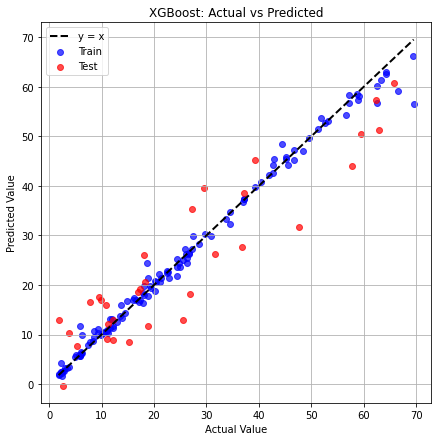

In [12]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=4,
    gamma=0.8,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_grain1.csv', index=False)


In [14]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/grain1_selected_features.pkl')

joblib.dump(model, 'model/grain1_xgb_model.pkl')

print("[Saved] model/grain1_selected_features.pkl")
print("[Saved] model/grain1_xgb_model.pkl")


[Saved] model/grain1_selected_features.pkl
[Saved] model/grain1_xgb_model.pkl


# 2.a1

In [2]:
data = pd.read_csv('data/compound_5_Structural_a1.csv').drop(columns=['compound'])
target_col = 'a_1'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

In [3]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(12)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 12
features: ['feat_16', 'feat_19', 'feat_7', 'feat_8', 'feat_3', 'feat_4', 'feat_15', 'feat_14', 'feat_2', 'feat_25', 'feat_11', 'feat_13']


5CV:
MSE: 0.8259 ± 0.4110
RMSE: 0.8716 ± 0.2572
MAE: 0.3897 ± 0.0595
R2: 0.7770 ± 0.1499


【train】:  MSE: 0.0968  RMSE: 0.3112  MAE: 0.1709, R2: 0.9760
【test】:  MSE: 0.1772  RMSE: 0.4210  MAE: 0.2772, R2: 0.9343


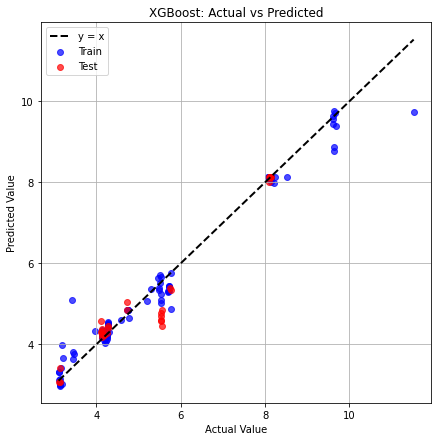

In [4]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=4,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_a1.csv', index=False)


In [6]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/a1_selected_features.pkl')

joblib.dump(model, 'model/a1_xgb_model.pkl')

print("[Saved] model/a1_selected_features.pkl")
print("[Saved] model/a1_xgb_model.pkl")


[Saved] model/a1_selected_features.pkl
[Saved] model/a1_xgb_model.pkl


# 3. b1

In [24]:
data = pd.read_csv('data/compound_5_Structural_b1.csv').drop(columns=['compound'])
target_col = 'b_1'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

In [25]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(12)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 12
features: ['feat_18', 'feat_19', 'feat_7', 'feat_8', 'feat_25', 'feat_3', 'feat_4', 'feat_15', 'feat_12', 'feat_2', 'feat_14', 'feat_1']


5CV:
MSE: 1.5257 ± 0.9899
RMSE: 1.1790 ± 0.3684
MAE: 0.4377 ± 0.0932
R2: 0.6595 ± 0.1415


【train】:  MSE: 0.1265  RMSE: 0.3557  MAE: 0.1487, R2: 0.9707
【test】:  MSE: 0.1179  RMSE: 0.3433  MAE: 0.2199, R2: 0.9563


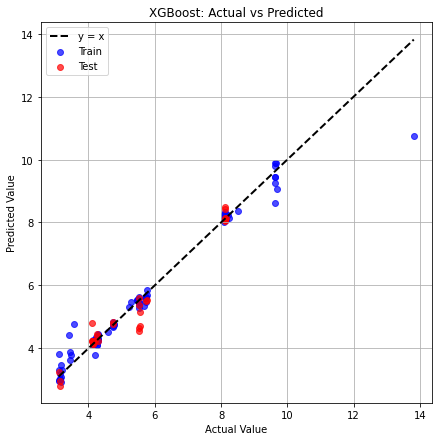

In [26]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,        
    learning_rate=0.06,      
    max_depth=3,             
    min_child_weight=6,      
    gamma=0.1,              
    subsample=0.75,          
    colsample_bytree=0.65,   
    reg_alpha=0.3,           
    reg_lambda=10.0,         
    random_state=24,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_b1.csv', index=False)


In [28]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/b1_selected_features.pkl')

joblib.dump(model, 'model/b1_xgb_model.pkl')

print("[Saved] model/b1_selected_features.pkl")
print("[Saved] model/b1_xgb_model.pkl")


[Saved] model/b1_selected_features.pkl
[Saved] model/b1_xgb_model.pkl


# 4.c1

In [31]:
data = pd.read_csv('data/compound_5_Structural_c1.csv').drop(columns=['compound'])
target_col = 'c_1'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(11)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 11
features: ['feat_14', 'feat_12', 'feat_5', 'feat_1', 'feat_4', 'feat_11', 'feat_9', 'feat_13', 'feat_8', 'feat_3', 'feat_6']


5CV:
MSE: 0.4522 ± 0.1790
RMSE: 0.6545 ± 0.1540
MAE: 0.3319 ± 0.0764
R2: 0.9146 ± 0.0603


【train】:  MSE: 0.0937  RMSE: 0.3060  MAE: 0.1516, R2: 0.9871
【test】:  MSE: 0.2985  RMSE: 0.5463  MAE: 0.2313, R2: 0.9598


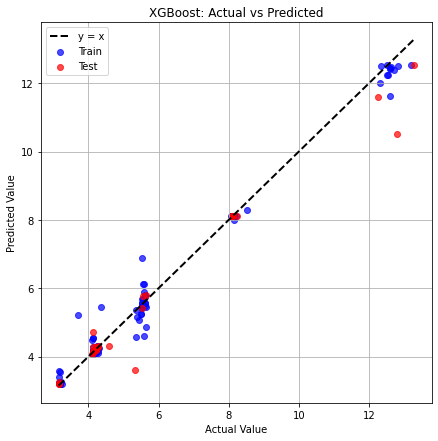

In [33]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=4,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_c1.csv', index=False)


In [35]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/c1_selected_features.pkl')

joblib.dump(model, 'model/c1_xgb_model.pkl')

print("[Saved] model/c1_selected_features.pkl")
print("[Saved] model/c1_xgb_model.pkl")


[Saved] model/c1_selected_features.pkl
[Saved] model/c1_xgb_model.pkl
